In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mean_df = pd.read_csv("results/curve_meanKNN.csv")
chi_df = pd.read_csv("results/curve_chiKNN.csv")
summary_df = pd.read_csv("results/summaryKNN.csv")

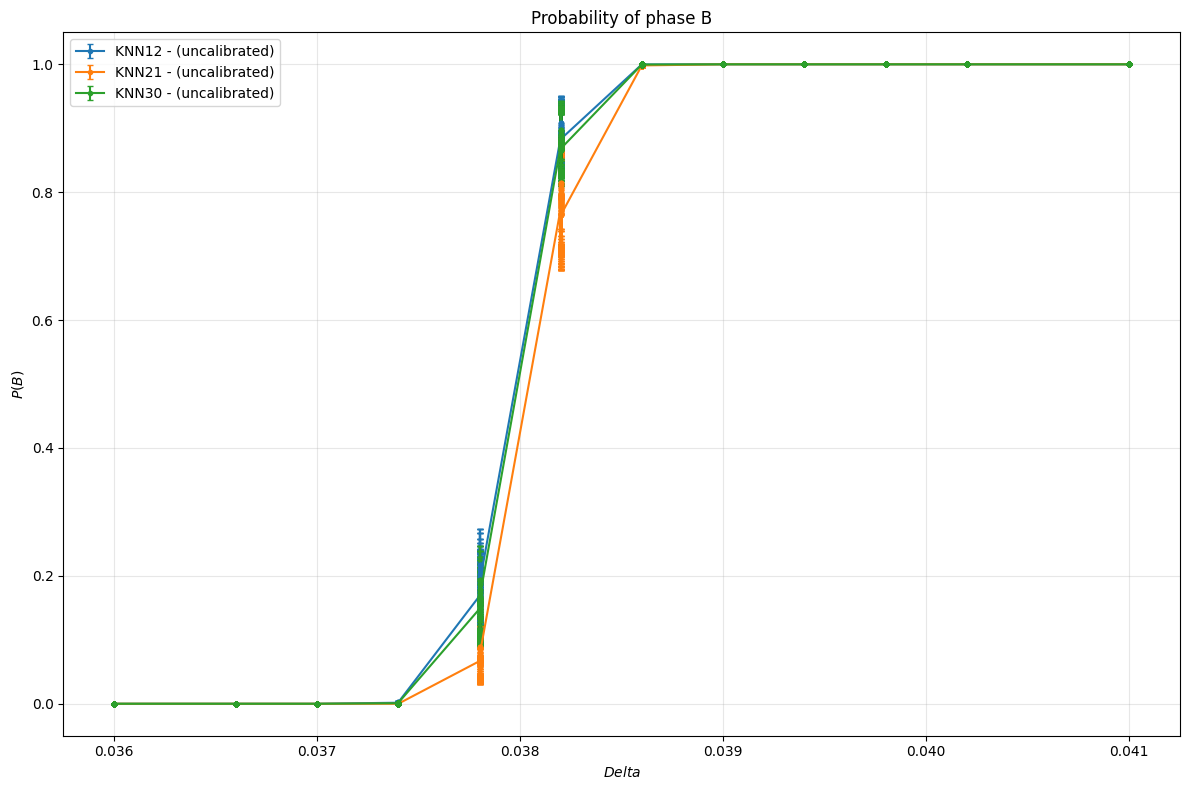

In [2]:
plt.figure(figsize=(12, 8))

for (feature_set, model, calibration), group in mean_df.groupby(
    ["feature_set", "model", "calibration"]
):
    # for 
    group = group.sort_values("Delta")

    plt.errorbar(
    group["Delta"],
    group["mean"],
    yerr=group["mean_err"],
    fmt="-o",
    markersize=3,
    capsize=2,
    linewidth=1.5,
    label=f"{model}{feature_set} - ({calibration})"
        )

plt.xlabel(r"$Delta$")
plt.ylabel(r"$P(B)$")
plt.title("Probability of phase B")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# plt.savefig(
#     "results/figures/probability_all_models.png",
#     dpi=300
# )

plt.show()

/tmp/ipykernel_5989/2991716031.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_5989/2991716031.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_5989/2991716031.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


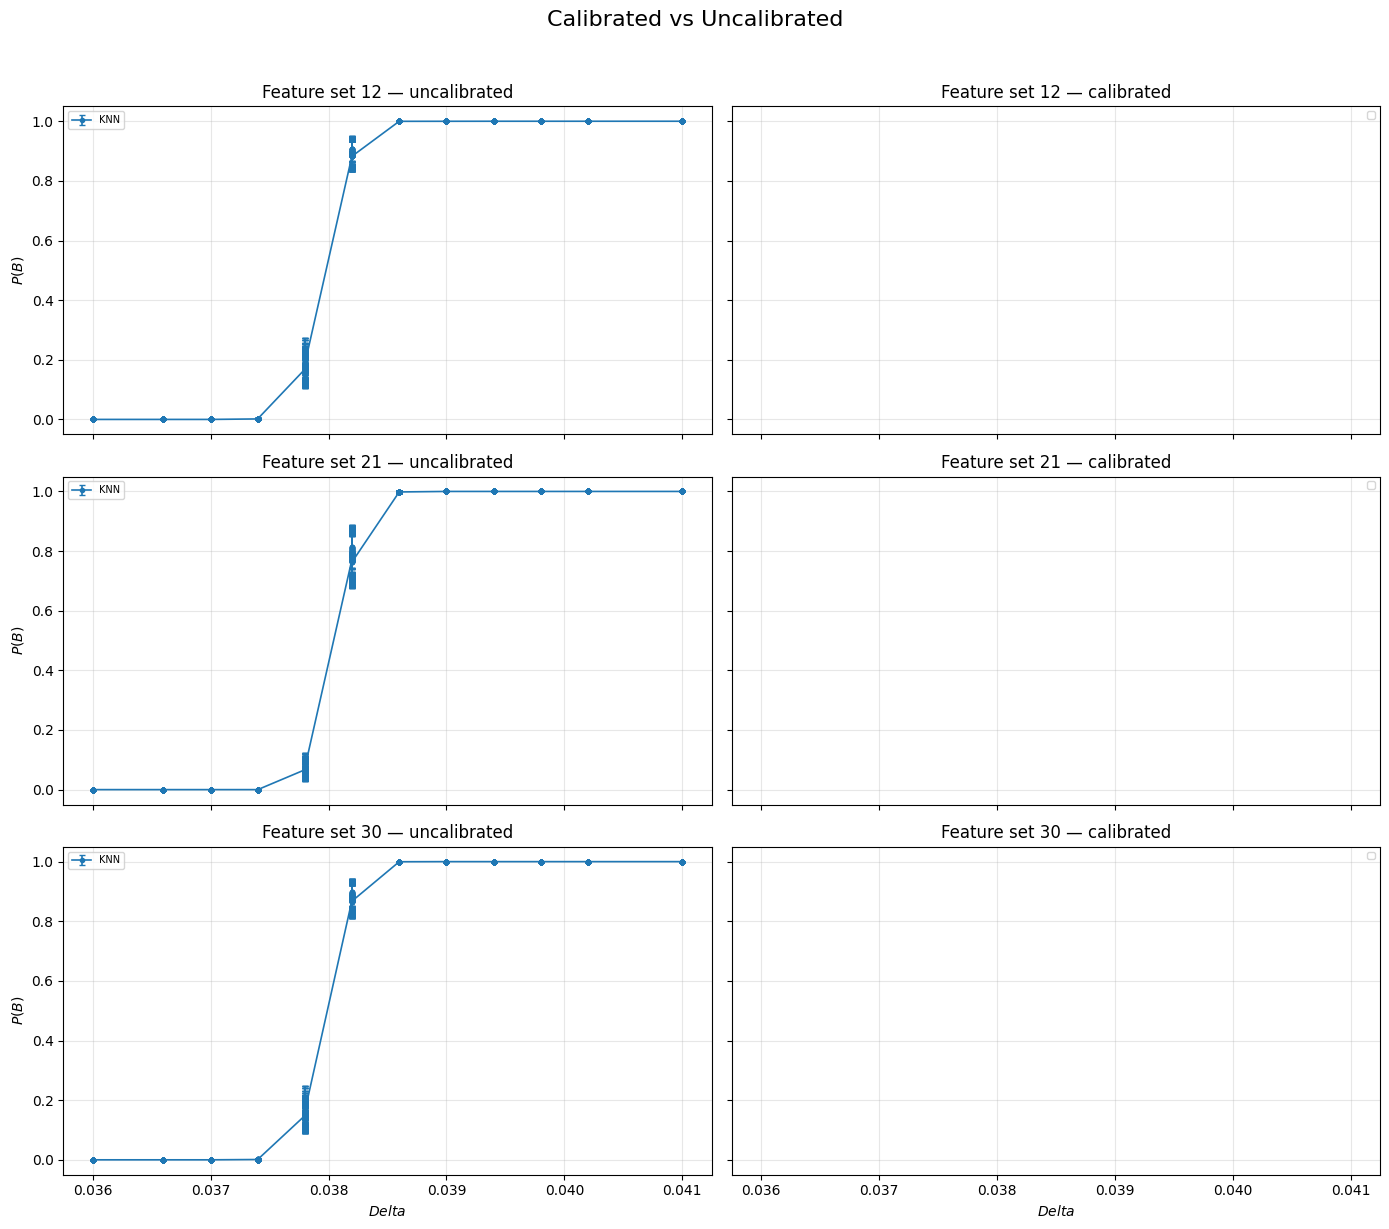

In [3]:
feature_sets = sorted(mean_df["feature_set"].unique())
calibrations = ["uncalibrated", "calibrated"]

fig, axes = plt.subplots(
    len(feature_sets),
    len(calibrations),
    figsize=(14, 4 * len(feature_sets)),
    sharex=True,
    sharey=True
)

# przypadek gdy jest tylko jeden feature_set
if len(feature_sets) == 1:
    axes = np.array([axes])

for i, fs in enumerate(feature_sets):

    for j, calib in enumerate(calibrations):

        ax = axes[i, j]

        df_plot = mean_df[
            (mean_df["feature_set"] == fs)
            &
            (mean_df["calibration"] == calib)
        ]

        for model, group in df_plot.groupby("model"):

            group = group.sort_values("Delta")

            ax.errorbar(
                group["Delta"],
                group["mean"],
                yerr=group["mean_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.2,
                label=model
            )

        ax.set_title(
            f"Feature set {fs} — {calib}"
        )

        ax.grid(alpha=0.3)

        if j == 0:
            ax.set_ylabel(r"$P(B)$")

        if i == len(feature_sets) - 1:
            ax.set_xlabel(r"$Delta$")

        ax.legend(
            fontsize=7,
            loc="best"
        )

plt.suptitle(
    "Calibrated vs Uncalibrated",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5989/1273590898.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_5989/1273590898.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_5989/1273590898.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


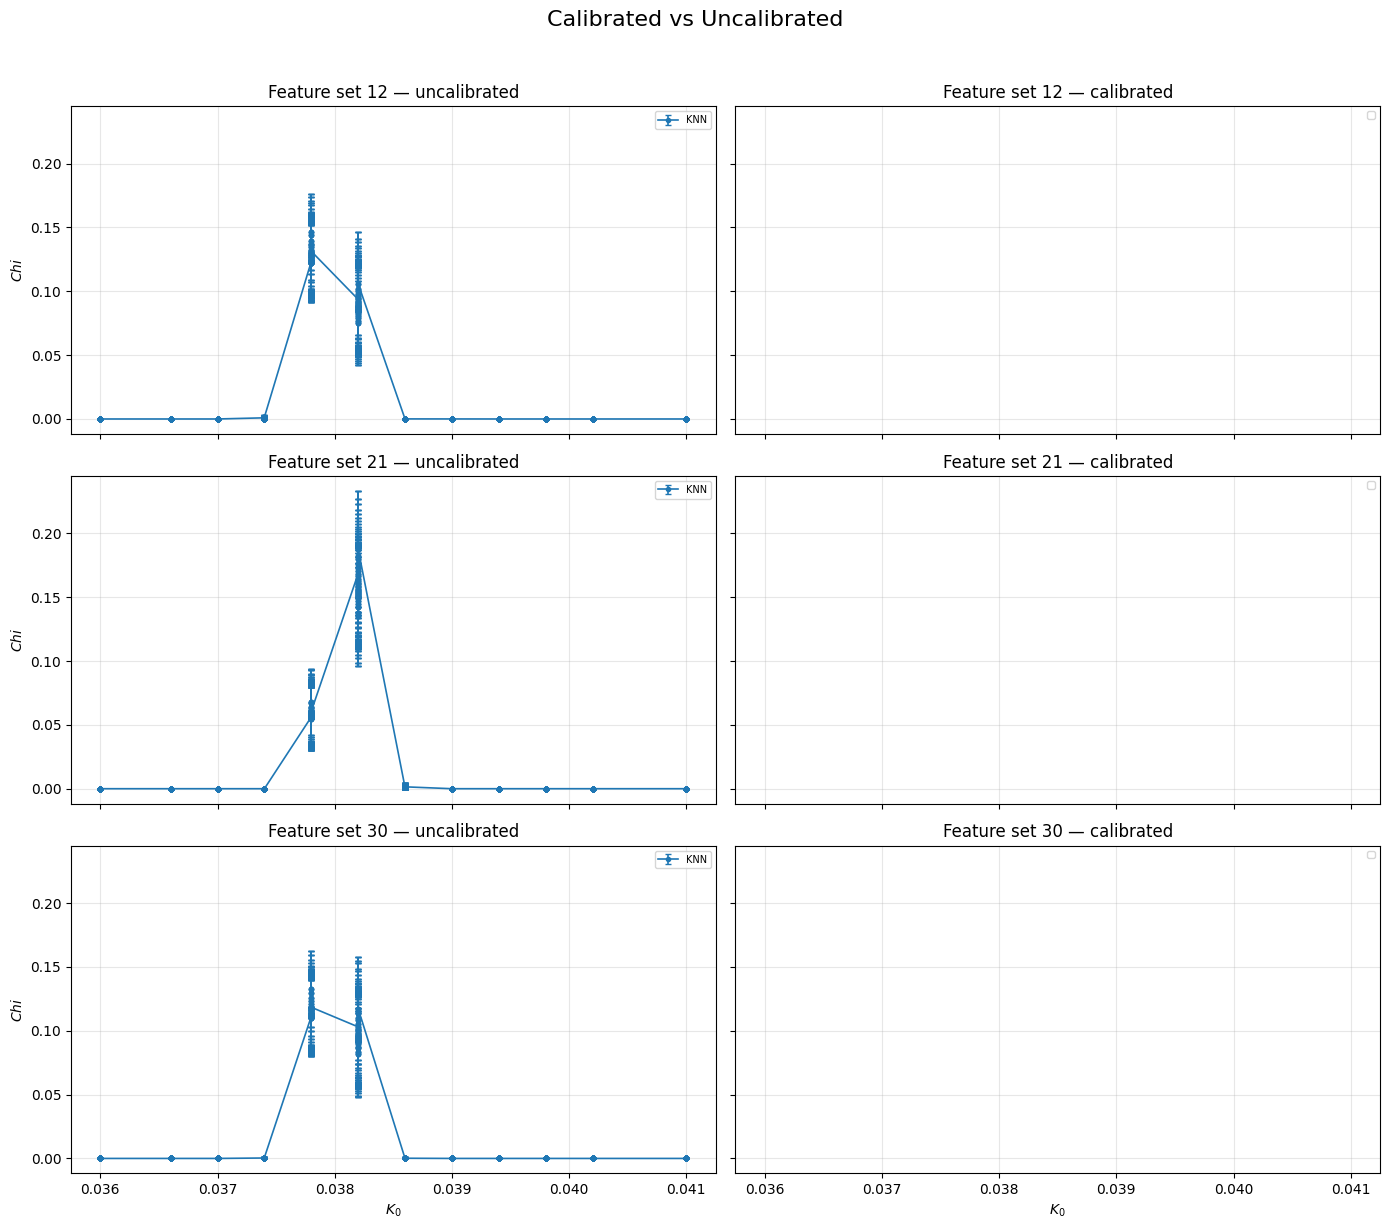

In [4]:
feature_sets = sorted(chi_df["feature_set"].unique())
calibrations = ["uncalibrated", "calibrated"]

fig, axes = plt.subplots(
    len(feature_sets),
    len(calibrations),
    figsize=(14, 4 * len(feature_sets)),
    sharex=True,
    sharey=True
)

# przypadek gdy jest tylko jeden feature_set
if len(feature_sets) == 1:
    axes = np.array([axes])

for i, fs in enumerate(feature_sets):

    for j, calib in enumerate(calibrations):

        ax = axes[i, j]

        df_plot = chi_df[
            (chi_df["feature_set"] == fs)
            &
            (chi_df["calibration"] == calib)
        ]

        for model, group in df_plot.groupby("model"):

            group = group.sort_values("Delta")

            ax.errorbar(
                group["Delta"],
                group["chi"],
                yerr=group["chi_err"],
                fmt="-o",
                markersize=3,
                capsize=2,
                linewidth=1.2,
                label=model
            )

        ax.set_title(
            f"Feature set {fs} — {calib}"
        )

        ax.grid(alpha=0.3)

        if j == 0:
            ax.set_ylabel(r"$Chi$")

        if i == len(feature_sets) - 1:
            ax.set_xlabel(r"$K_0$")

        ax.legend(
            fontsize=7,
            loc="best"
        )

plt.suptitle(
    "Calibrated vs Uncalibrated",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [5]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "calibration",
            "K0_crit",
            "K0_crit_err",
            "K0_close",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "calibration"]
    )
)

print(table.to_string(index=False))

KeyError: "['K0_crit', 'K0_crit_err', 'K0_close'] not in index"

In [ ]:
table = (
    summary_df[
        [
            "model",
            "n_features",
            "calibration",
            "K0_crit",
            "K0_crit_err",
            "runtime_total",
        ]
    ]
    .sort_values(
        ["model", "n_features", "calibration"]
    )
)

table["K0_crit"] = table["K0_crit"].round(4)
table["K0_crit_err"] = table["K0_crit_err"].round(4)
table["runtime_total"] = table["runtime_total"].round(2)

print(table.to_string(index=False))

In [ ]:
print(
    summary_df[
        [
            "model",
            "calibration",
            "K0_crit",
            "K0_crit_err",
        ]
    ].to_latex(
        index=False,
        float_format="%.5f"
    )
)

In [ ]:
table = summary_df.copy()

table["K0"] = (
    table["K0_crit"].round(4).astype(str)
    + " ± "
    + table["K0_crit_err"].round(4).astype(str)
)

table = table[
    [
        "model",
        "n_features",
        "calibration",
        "K0",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model", "n_features", "calibration"]
)

print(table.to_string(index=False))

In [ ]:
summary_table = (
    summary_df
    .groupby(
        ["n_features", "calibration"]
    )
    .agg(
        K0_crit_mean=("K0_crit", "mean"),
        K0_crit_std=("K0_crit", "std"),
        Err_mean=("K0_crit_err", "mean"),
        Runtime_mean=("runtime_total", "mean"),
        N_models=("model", "nunique")
    )
    .reset_index()
)

print(summary_table.round(4).to_string(index=False))

In [ ]:
table = summary_df.copy()

table = table[
    (table["n_features"] == 30)
    &
    (table["calibration"] == "uncalibrated")
    ]

table = table[
    [
        "model",
        "K0_close",
        "runtime_total",
    ]
]

table = table.sort_values(
    ["model"]
)

print(table.to_string(index=False))